# TOPOTEX Dataset Inspector

Dataset（`output/topotex_dataset`，schema `topotex_dataset@1`）：
每个样本 = reference image + 六视角 MV + mesh + **三个训练 query + 一个 held-out query**：

| query | 类型 | 说明 |
|---|---|---|
| `uv_000` | canonical UV | 原生 GLB 参数化 |
| `uv_001` | alternative UV family | xatlas 重参数化，面序逐位保持 |
| `uv_002` | **partial surface query** | 确定性连通面子集（25/50/75%），重光栅化 + 重烘焙 GT |
| `uv_test` | held-out family | Blender Smart UV，仅评估 |

每个 query 提供 `face_id [H,W]`、`barycentric [3,H,W]`、`valid_mask`、`gt_texture`。

In [1]:
import json, sys
from pathlib import Path
p = Path.cwd()
PROJECT_ROOT = next(c for c in (p, *p.parents) if (c / "configs").exists())
sys.path.insert(0, str(PROJECT_ROOT))
DATASET_ROOT = PROJECT_ROOT / "output" / "topotex_dataset"

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

matplotlib.rcParams["font.sans-serif"] = ["Noto Sans CJK SC",
                                          "Noto Sans CJK JP", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
assert (DATASET_ROOT / "manifest.jsonl").exists(), (
    "dataset not built - run: python -m topotex.data.builder ... then "
    "python -m topotex.data.builder (see README, Dataset section)")
ids = [json.loads(l)["sample_id"]
       for l in open(DATASET_ROOT / "manifest.jsonl")]
print("dataset samples:", len(ids))

dataset samples: 1982


## 输入数据：reference / multi-view / mesh

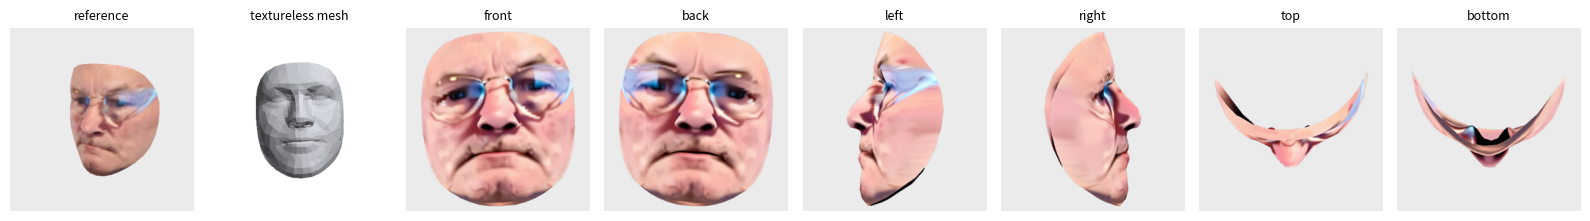

sample        : 02aca39544f641b88bdbc2b1b9aa7f77
mesh stats    : V=468  F=898  bbox extent=[0.154 0.174 0.097]
face area     : total 0.0350 | min 2.51e-07 | median 2.24e-05
mv tensor     : (6, 3, 256, 256) uint8
build_seconds : 0.7


In [2]:
import random
from safetensors.numpy import load_file
from topotex.data.mesh import CANONICAL_VIEWS, camera_matrices, rasterize_view

RANDOM_SAMPLE = True
SAMPLE_ID = None            # set to a sample id string to pin the sample
sid = SAMPLE_ID or (random.choice(ids) if RANDOM_SAMPLE else ids[0])
d = DATASET_ROOT / "samples" / sid
mesh = load_file(str(d / "mesh.safetensors"))
mv = load_file(str(d / "mv.safetensors"))["images"]
V = mesh["vertices"].astype(np.float64)
F = mesh["faces"].astype(np.int64)

def render_white(vi, res=384):
    _, az, el = CANONICAL_VIEWS[vi]
    gb = rasterize_view(V, F, camera_matrices(az, el, V.min(0), V.max(0)), res)
    tri = V[F]
    n = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
    n /= np.clip(np.linalg.norm(n, axis=1, keepdims=True), 1e-12, None)
    lam = np.abs(n @ (np.array([0.4, 0.6, 0.7]) / np.linalg.norm([0.4, 0.6, 0.7])))
    img = np.ones((res, res, 3))
    m = gb["mask"]
    img[m] = (0.25 + 0.75 * lam[gb["face_id"][m]])[:, None] *              np.array([0.86, 0.87, 0.90])
    return img

fig = plt.figure(figsize=(16, 3))
ax = fig.add_subplot(1, 8, 1)
ax.imshow(np.asarray(Image.open(d / "reference.png").convert("RGB")))
ax.set_title("reference", fontsize=9); ax.axis("off")
ax = fig.add_subplot(1, 8, 2)
if torch.cuda.is_available():
    ax.imshow(render_white(0))
ax.set_title("textureless mesh", fontsize=9); ax.axis("off")
for i in range(6):
    ax = fig.add_subplot(1, 8, i + 3)
    ax.imshow(mv[i].transpose(1, 2, 0))
    ax.set_title(CANONICAL_VIEWS[i][0], fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

tri = V[F]
areas = np.linalg.norm(np.cross(tri[:, 1] - tri[:, 0],
                                tri[:, 2] - tri[:, 0]), axis=1) / 2
meta = json.loads((d / "meta.json").read_text())
print("sample        :", sid)
print("mesh stats    : V=%d  F=%d  bbox extent=%s" %
      (len(V), len(F), np.round(V.max(0) - V.min(0), 3)))
print("face area     : total %.4f | min %.2e | median %.2e" %
      (areas.sum(), areas.min(), np.median(areas)))
print("mv tensor     :", mv.shape, mv.dtype)
print("build_seconds :", meta.get("build_seconds"))

## 三个 UV query + held-out：face_id / barycentric / valid / GT

`uv_002` 是 **partial surface query**：只有连通面子集被光栅化，
地址图由子集自身的光栅化产生（非 mask 全图），GT 在有效区重烘焙、区外为 0。

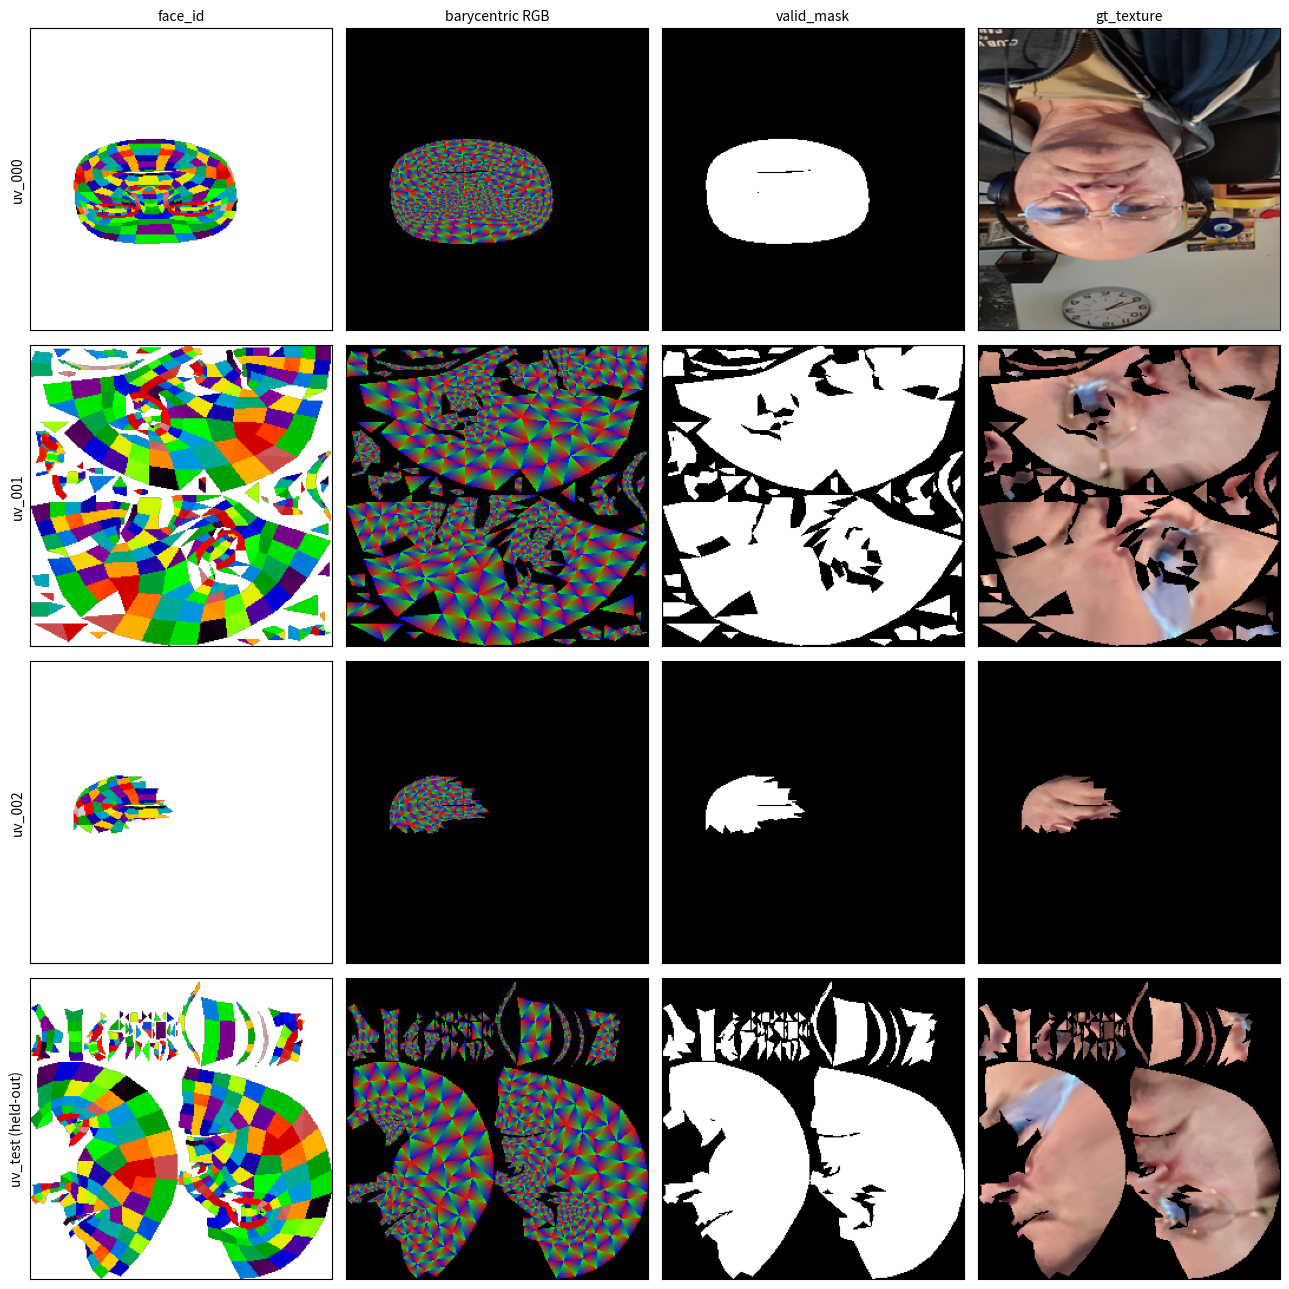

[
 {
  "name": "uv_000",
  "type": "canonical",
  "held_out": false,
  "valid_texels": 10342,
  "n_uv_vertices": 468,
  "face_id_sha256": "b5cbff8efed89108fba5a8a818e503ca0f9c18787f6933307ed863a15697089f",
  "barycentric_sha256": "fb94af8d3d16a749ec39186fb64a08d1e5426a89beadddf4b7fdbae76524df4c"
 },
 {
  "name": "uv_001",
  "type": "alternative",
  "held_out": false,
  "valid_texels": 45696,
  "n_uv_vertices": 706,
  "face_id_sha256": "b928227ca02149b3271cb02cb7d8c2790bd5064fe57153826e5fa7698b107a92",
  "barycentric_sha256": "3f50bac3633513cfae701179b6e755bcebfc75b0ae695763cc8115a97c8b5614"
 },
 {
  "name": "uv_002",
  "type": "partial",
  "held_out": false,
  "valid_texels": 2662,
  "n_uv_vertices": 468,
  "partial_frac": 0.25,
  "n_kept_faces": 224,
  "face_id_sha256": "136c3dbcc8c46a663644ade462f8541dfe7313c5a0391824e882f9704f1f69b7",
  "barycentric_sha256": "6350fa3d34692b8b2e99ee6c65ac4c5cf867cc29ff751536f119844a944600bb"
 },
 {
  "name": "uv_test",
  "type": "heldout",
  "held_ou

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
row_meta = json.loads((d / "meta.json").read_text())["uv_queries"]
for r, q in enumerate(["uv_000", "uv_001", "uv_002", "uv_test"]):
    ua = load_file(str(d / "uv_queries" / q / "uv_address.safetensors"))
    fid = ua["face_id"].astype(np.float64); fid[fid < 0] = np.nan
    valid = ua["valid_mask"].astype(bool)
    bary = ua["barycentric"].astype(np.float64).transpose(1, 2, 0)
    bary[~valid] = 0
    gt = np.asarray(Image.open(d / "uv_queries" / q / "gt_texture.png"))
    axes[r][0].imshow(fid, cmap="nipy_spectral")
    lbl = q + (" (held-out)" if q == "uv_test" else "")
    axes[r][0].set_ylabel(lbl, fontsize=10)
    axes[r][1].imshow(bary)
    axes[r][2].imshow(valid, cmap="gray")
    axes[r][3].imshow(gt)
for c, t in enumerate(["face_id", "barycentric RGB", "valid_mask",
                       "gt_texture"]):
    axes[0][c].set_title(t, fontsize=10)
for a in axes.ravel():
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print(json.dumps(row_meta, indent=1))

## UV layout — 各 query 的 2D 参数化线框

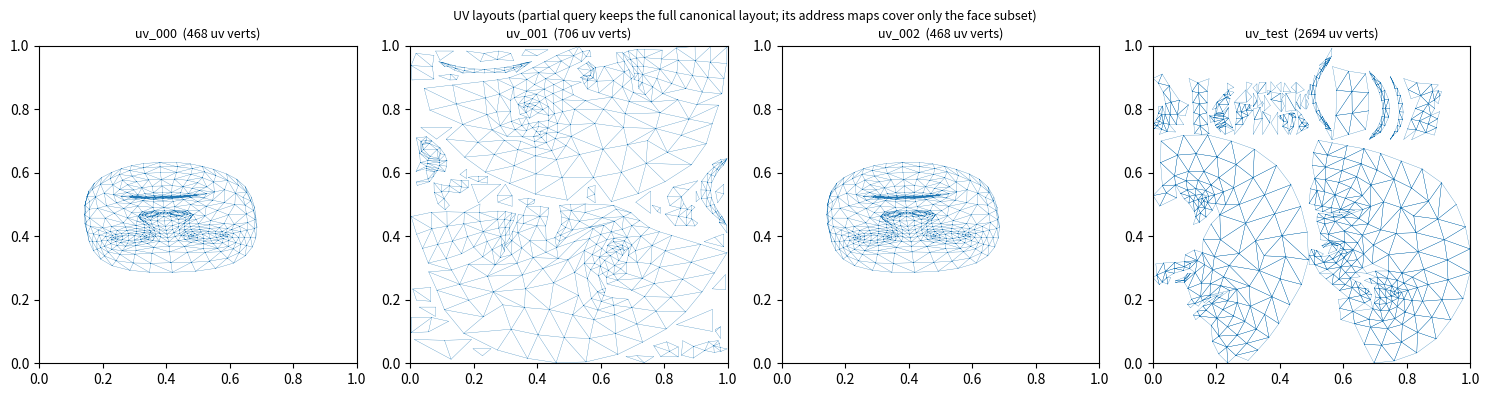

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, q in zip(axes, ["uv_000", "uv_001", "uv_002", "uv_test"]):
    ua = load_file(str(d / "uv_queries" / q / "uv_address.safetensors"))
    uvv, uvf = ua["uv_vertices"], ua["uv_faces"].astype(np.int64)
    ax.triplot(uvv[:, 0], 1 - uvv[:, 1], uvf, lw=0.2, color="tab:blue")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect(1)
    ax.set_title(q + "  (%d uv verts)" % len(uvv), fontsize=9)
plt.suptitle("UV layouts (partial query keeps the full canonical layout; "
             "its address maps cover only the face subset)", fontsize=9)
plt.tight_layout(); plt.show()

## Dataset statistics（dataset_statistics.json，仅监控不过滤）

由 `python -m topotex.data.statistics` 生成：构建成功率、失败原因、
面数/顶点分布、各 query 的 UV 占用率分布。

source samples : 1987 | failed: 13 | success rate: 0.9935 | MV ok: 1987
uv-query samples: 1982
failure reasons: {'reference render empty': 13}


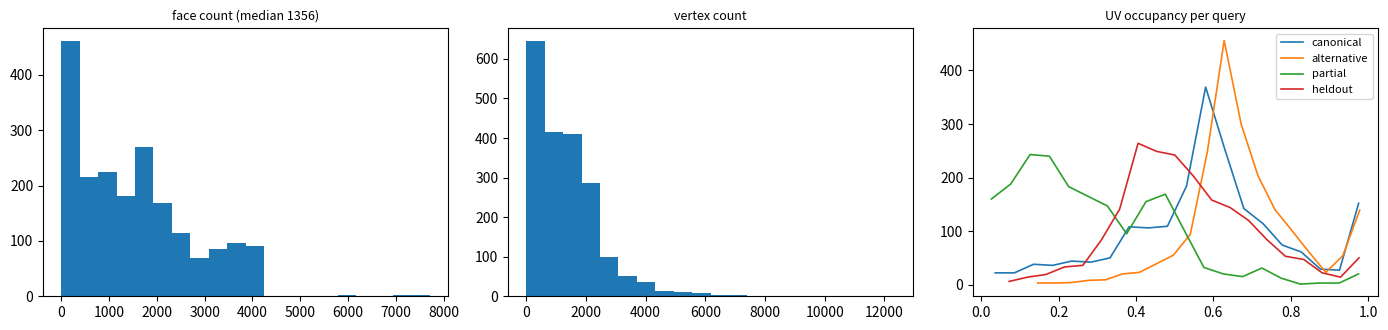

In [5]:
sp = DATASET_ROOT / "dataset_statistics.json"
if not sp.exists():
    print("dataset_statistics.json not generated yet — run "
          "python -m topotex.data.statistics")
else:
    st = json.loads(sp.read_text())
    src, uvq = st["source"], st["uv_query_dataset"]
    print("source samples :", src["total_samples"],
          "| failed:", src["failed"],
          "| success rate:", src["success_rate"],
          "| MV ok:", src["mv_generation_ok"])
    print("uv-query samples:", uvq["total_samples"])
    if src["failed_reasons"]:
        print("failure reasons:", src["failed_reasons"])
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
    fc = src["face_count"]["hist"]
    axes[0].bar(fc["edges"][:-1], fc["counts"],
                width=np.diff(fc["edges"]), align="edge")
    axes[0].set_title("face count (median %d)"
                      % src["face_count"]["median"], fontsize=9)
    vc = src["vertex_count"]["hist"]
    axes[1].bar(vc["edges"][:-1], vc["counts"],
                width=np.diff(vc["edges"]), align="edge")
    axes[1].set_title("vertex count", fontsize=9)
    for nm, o in uvq["uv_occupancy"].items():
        h = o["hist"]
        centers = [(h["edges"][i] + h["edges"][i + 1]) / 2
                   for i in range(len(h["counts"]))]
        axes[2].plot(centers, h["counts"], label=nm, lw=1.2)
    axes[2].legend(fontsize=8)
    axes[2].set_title("UV occupancy per query", fontsize=9)
    plt.tight_layout(); plt.show()

## Partial query 全数据集统计（fraction / texel 覆盖）

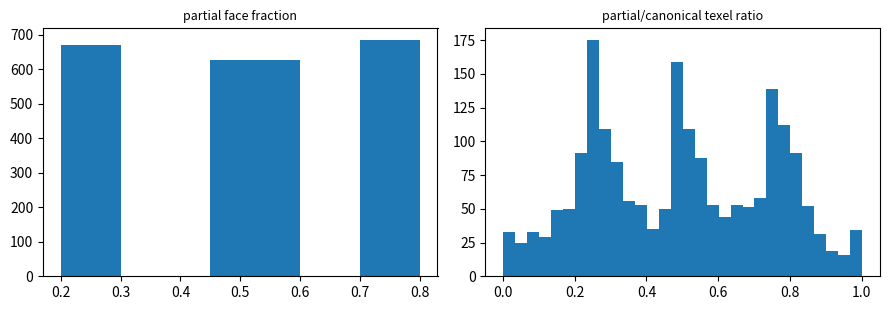

n=1982 | frac counts: {0.25: 671, 0.5: 627, 0.75: 684} | ratio median 0.500 min 0.001


In [6]:
fracs, ratios = [], []
for s in ids:
    m = json.loads((DATASET_ROOT / "samples" / s / "meta.json").read_text())
    qs = {q["name"]: q for q in m["uv_queries"]}
    fracs.append(qs["uv_002"]["partial_frac"])
    ratios.append(qs["uv_002"]["valid_texels"]
                  / max(qs["uv_000"]["valid_texels"], 1))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(fracs, bins=[0.2, 0.3, 0.45, 0.6, 0.7, 0.8])
axes[0].set_title("partial face fraction", fontsize=9)
axes[1].hist(ratios, bins=30)
axes[1].set_title("partial/canonical texel ratio", fontsize=9)
plt.tight_layout(); plt.show()
print("n=%d | frac counts:" % len(ids),
      {f: fracs.count(f) for f in (0.25, 0.5, 0.75)},
      "| ratio median %.3f min %.3f" % (float(np.median(ratios)),
                                        float(np.min(ratios))))